## TC 5033
## Deep Learning
## Transformers

#### Activity 4: Implementing a Translator

**Team Members:**

Hiram García Austria - A00378771

David Felipe Hernandez Chiapa - A01797374

Gerardo Armando Ávila Velásquez - A01797373





- Objective

To understand the Transformer Architecture by Implementing a translator.

- Instructions

    This activity requires submission in teams. While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Follow the provided code. The code already implements a transformer from scratch as explained in one of [week's 9 videos](https://youtu.be/XefFj4rLHgU)

    Since the provided code already implements a simple translator, your job for this assignment is to understand it fully, and document it using pictures, figures, and markdown cells.  You should test your translator with at least 10 sentences. The dataset used for this task was obtained from [Tatoeba, a large dataset of sentences and translations](https://tatoeba.org/en/downloads).
  
- Evaluation Criteria

    - Code Readability and Comments
    - Traning a translator
    - Translating at least 10 sentences.

- Submission

Submit this Jupyter Notebook in canvas with your complete solution, ensuring your code is well-commented and includes Markdown cells that explain your design choices, results, and any challenges you encountered.



In [1]:
import pandas as pd

input_tsv_path = '/content/Parejas de oraciones en InglésEspañol - 2026-03-21.tsv'
output_csv_path = '/content/Parejas de oraciones en InglésEspañol - 2026-03-21.csv'

# get the original file, specifying the separator and getting rid of bad lines
df = pd.read_csv(input_tsv_path, sep='\t', on_bad_lines='skip')

# Saving the DataFrame to a CSV file
df.to_csv(output_csv_path, index=False)

print(f'CSV fILE is ready: {output_csv_path}')

CSV fILE is ready: /content/Parejas de oraciones en InglésEspañol - 2026-03-21.csv


The code in the previous cell, leverages the pandas library to seamlessly convert a Tab-Separated Values (TSV) file into a Comma-Separated Values (CSV) file. It begins by importing the pandas module and defining the file paths for both the source TSV and the target CSV. The TSV file is then ingested into a pandas DataFrame, with error handling configured to bypass any malformed lines. Finally, the DataFrame is exported as a CSV file, ensuring a clean output by excluding the index column.

#### Script to convert csv to text file

In [2]:
#This script requires to convert the TSV file to CSV
# easiest way is to open it in Calc or excel and save as csv
PATH = '/content/Parejas de oraciones en InglésEspañol - 2026-03-21.csv'
import pandas as pd
df = pd.read_csv(PATH, sep=',') # Changed separator to comma for CSV file

In [3]:
eng_spa_cols = df.iloc[:, [1, 3]].copy()
eng_spa_cols['length'] = eng_spa_cols.iloc[:, 0].str.len()
eng_spa_cols = eng_spa_cols.sort_values(by='length')
eng_spa_cols = eng_spa_cols.drop(columns=['length'])

output_file_path = '/content/eng-spa4.txt' # Changed output path to /content/
eng_spa_cols.to_csv(output_file_path, sep='\t', index=False, header=False)

In the previous cells two specific columns from a DataFrame are selected (1 and 3), then a temporary column to measure string length is added, data is sorted accordingly. After ordering the rows from shortest to longest, the temporary column is removed. The refined DataFrame is then exported as a tab‑delimited text file without indexes or headers.

## Transformer - Attention is all you need

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math
import numpy as np
import re

torch.manual_seed(23)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
MAX_SEQ_LEN = 128

In the next cell we will define the architecture of our transformer, based on the one propossed on the "Atention is all you need" paper.

The following classes are created as the backbone of the model:

 **PositionalEmbedding**: Adds positional information to word embeddings, enabling the model to understand word order. A matrix of sinusoidal functions is generated. These functions are added to the word embeddings, providing the model with a way to trace back the word order

**MultiHeadAttention**: The most relevant mechanism in the transformer model, it lets the model focus on different parts of the input simultaneously. It computes attention scores across multiple heads to capture diverse relationships.

 It considers 3 inputs: Query (Q), Key (K), and Value (V). Then calculates attention scores (dot product of Q and K, scaled by the square root of the dimension of K), applies a softmax function, and then multiplies these by V. The results from all heads are concatenated and then projected to the original dimension.

Whithin this class we can see the **scale_dot_product** method that calculates attention weights by combining queries, keys, and values.

**PositionFeedForward**: Applies fc neural transformations independently to each token’s representation. It has two linear transformations and a ReLU activation function

**EncoderSubLayer**: this class bundles self‑attention (Multi-head), feed‑forward networks with normalization and dropout for stable training whitin the encoder.

 It applies self-attention (for Q, K, V as the input x), then a dropout and layer normalization. After that, it applies the feed-forward network, another dropout, and another layer normalization.

**Encoder Stack**: This is a stack of  multiple encoder sub‑layers to build rich input representations. It takes the input x to each EncoderSubLayer in a sequential way, and allows an optional masking.

**Decoder Sub‑Layer**: Conceptually speaking is similar to the Encoder sublayer but with the following differences: 1) adds masked self‑attention and 2)cross‑attention to incorporate both target and encoder outputs respectivelly.

**Decoder Stack**: Layers multiple decoder sub‑layers to generate the output sequence step by step, using both the encoder’s output and previously generated tokens. applying both target and encoder masks

This high level diagram ilustrates the model flow
 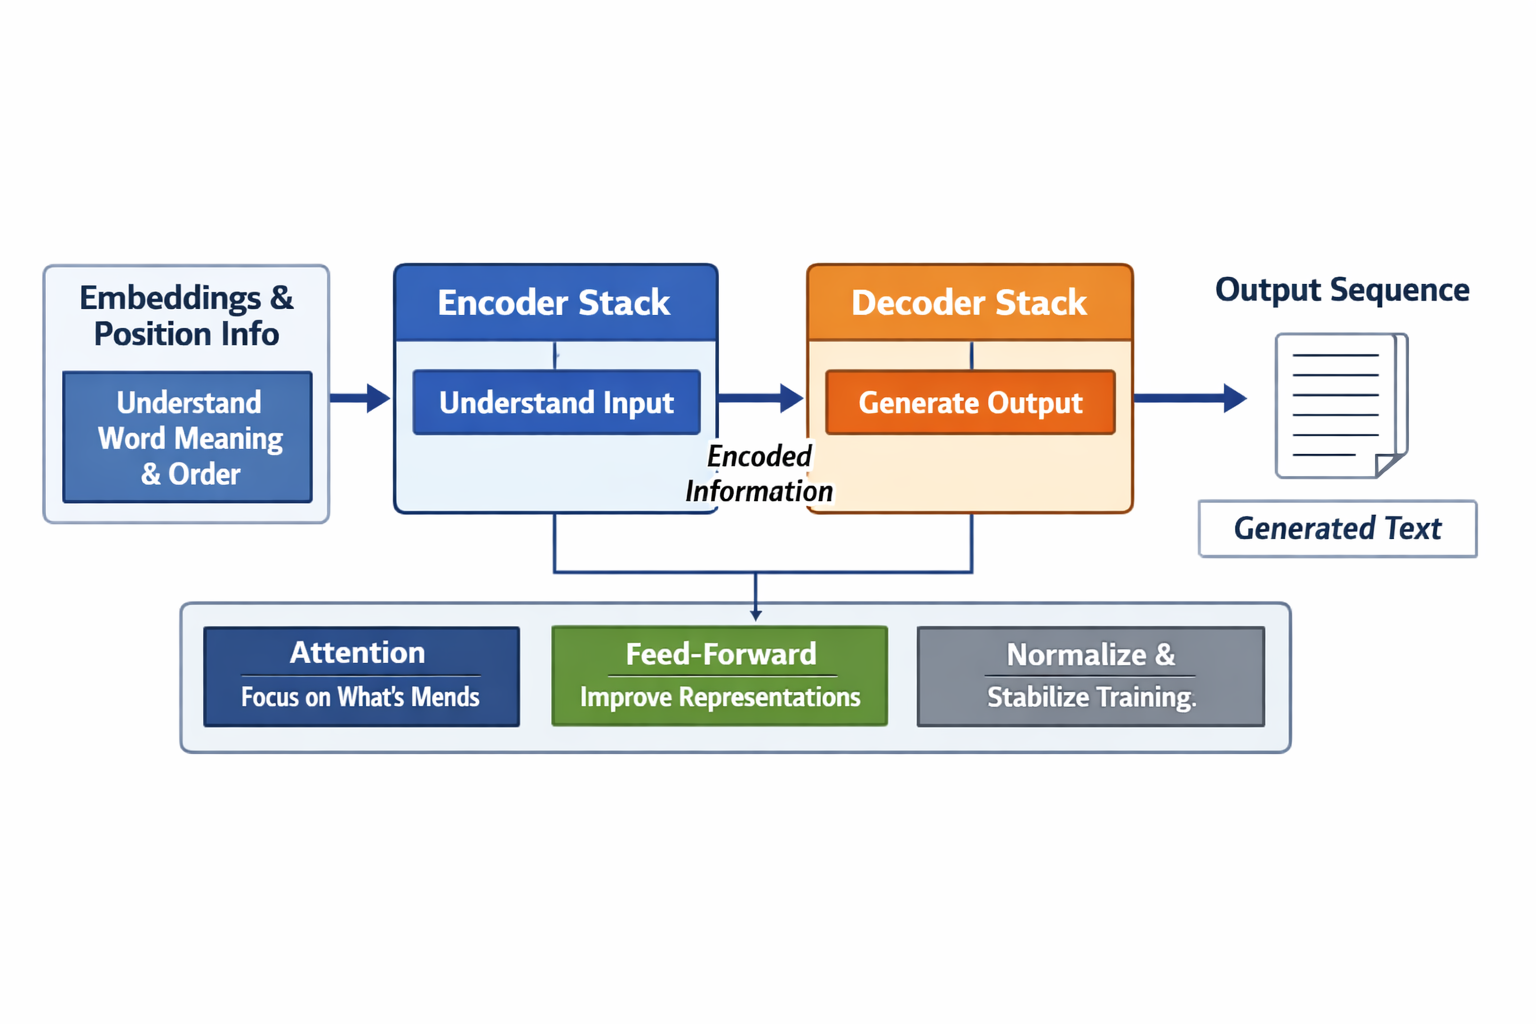

In [7]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_len = MAX_SEQ_LEN):
        super().__init__()
        self.pos_embed_matrix = torch.zeros(max_seq_len, d_model, device=device)
        token_pos = torch.arange(0, max_seq_len, dtype = torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0)/d_model))
        self.pos_embed_matrix[:, 0::2] = torch.sin(token_pos * div_term)
        self.pos_embed_matrix[:, 1::2] = torch.cos(token_pos * div_term)
        self.pos_embed_matrix = self.pos_embed_matrix.unsqueeze(0).transpose(0,1)

    def forward(self, x):
#         print(self.pos_embed_matrix.shape)
#         print(x.shape)
        return x + self.pos_embed_matrix[:x.size(0), :]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model = 512, num_heads = 8):
        super().__init__()
        assert d_model % num_heads == 0, 'Embedding size not compatible with num heads'

# d_v and d_k are the dimensions of the value and key/query vectors for each attention head.
# Each head will process a reduced dimension (d_model / num_heads).
        self.d_v = d_model // num_heads
        self.d_k = self.d_v
        self.num_heads = num_heads

# W_q, W_k, W_v are linear layers that project the input (Q, K, V) to a larger dimension (d_model).
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # W_o combines the concatenated outputs of all attention heads.

    def forward(self, Q, K, V, mask = None):
        batch_size = Q.size(0)


        # Q, K, V inputs are passed through their respective layers (W_q, W_k, W_v).
        # The result is reshaped to explicitly divide the last `d_model` dimension into `num_heads` heads, each with dimension.
        # Then, the tensor is transposed so that the head dimensions alligns to the `batch_size`, facilitating parallel processing of each head.

        '''
        Q, K, V -> [batch_size, seq_len, num_heads*d_k]
        after transpose Q, K, V -> [batch_size, num_heads, seq_len, d_k]
        '''
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2 )

        # The `scale_dot_product` method is called to compute the weighted values
        # and attention weights for each attention head. This is the actual
        # attention mechanism

        weighted_values, attention = self.scale_dot_product(Q, K, V, mask)
        weighted_values = weighted_values.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads*self.d_k)
        weighted_values = self.W_o(weighted_values)

        return weighted_values, attention

        # This method calculates attention weights and applies them to the values.
    def scale_dot_product(self, Q, K, V, mask = None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k) # The result is scaled to prevent gradients from becoming too large.
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attention = F.softmax(scores, dim = -1) # Apply softmax along the last dimension to obtain attention probabilities
        weighted_values = torch.matmul(attention, V) # This produces a weighted sum of values, where weights are attention probabilities.

        return weighted_values, attention


class PositionFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x))) #two linear transformations with a ReLU activation in between

class EncoderSubLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout = 0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PositionFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.droupout1 = nn.Dropout(dropout)
        self.droupout2 = nn.Dropout(dropout)

    def forward(self, x, mask = None):
        attention_score, _ = self.self_attn(x, x, x, mask)
        x = x + self.droupout1(attention_score) # Residual connection, original value is added to the attention score
        x = self.norm1(x)
        x = x + self.droupout2(self.ffn(x)) # 2nd residual connection
        return self.norm2(x) # After normalization this is the output to be passed

# Controls the pass of the input x through each encoder sublayer
class Encoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([EncoderSubLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

class DecoderSubLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads) # Allows the decoder to attend to previous positions preventing it from 'seeing' future tokens that it hasn't generated yet.
        self.cross_attn = MultiHeadAttention(d_model, num_heads) # Allows the decoder to attend to the encoder's output. Here, the query comes from the decoder's self-attention output, and the key and value come from the encoder's output.
        self.feed_forward = PositionFeedForward(d_model, d_ff)  # It processes the representations generated by the attention layers to refine the information.
        self.norm1 = nn.LayerNorm(d_model) #Normalization stabilize training and improve convergence applied after each sub-layer
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout) #Dropout applied after residual connections prevent overfitting during training
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, encoder_output, target_mask=None, encoder_mask=None):
        attention_score, _ = self.self_attn(x, x, x, target_mask) # First sub-layer: Masked Self-Attention
        x = x + self.dropout1(attention_score)
        x = self.norm1(x)

        encoder_attn, _ = self.cross_attn(x, encoder_output, encoder_output, encoder_mask) #Second sub-layer: Cross-Attention
        x = x + self.dropout2(encoder_attn)
        x = self.norm2(x)

        ff_output = self.feed_forward(x) #Third sub-layer: Feed-Forward
        x = x + self.dropout3(ff_output)
        return self.norm3(x)

class Decoder(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([DecoderSubLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, target_mask, encoder_mask):
        for layer in self.layers:
            x = layer(x, encoder_output, target_mask, encoder_mask)
        return self.norm(x)

This additional diagram explains the relationship between Encoder and Decoder with greater detail
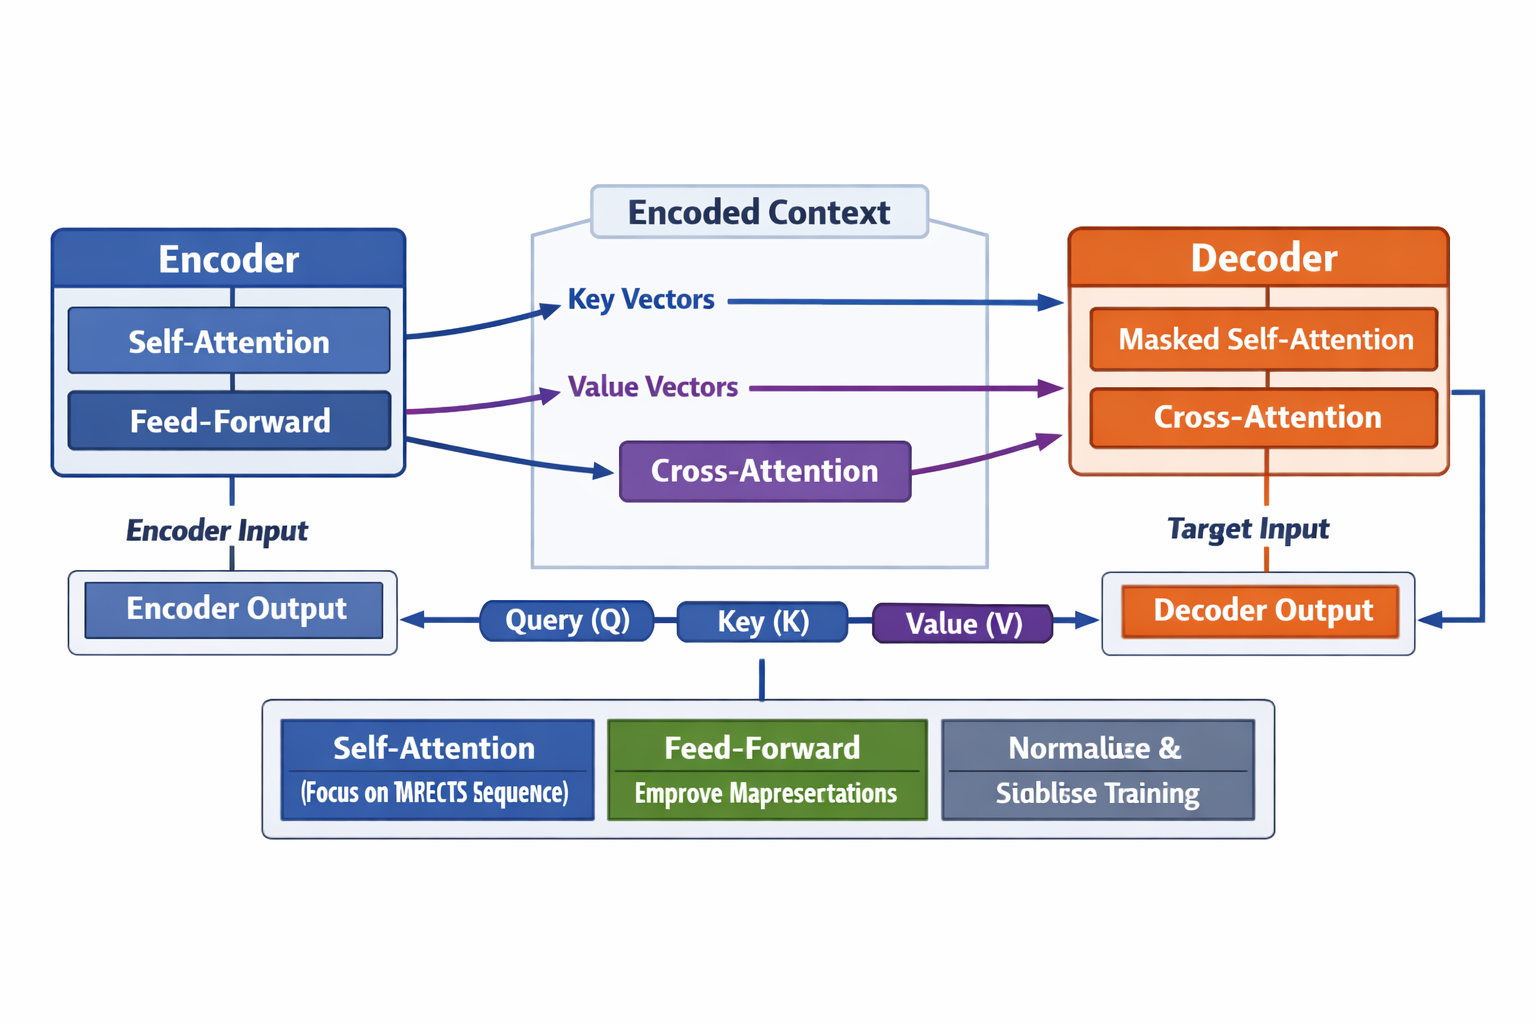

The Transformer class is the complete model that integrates all the previously defined components (embeddings, positional encoding, encoder, and decoder). Basically it makes possible to orchestrate the whole thing  

In [8]:
class Transformer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers,
                 input_vocab_size, target_vocab_size,
                 max_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.encoder_embedding = nn.Embedding(input_vocab_size, d_model) # Converts input tokens into vectors of size `d_model`
        self.decoder_embedding = nn.Embedding(target_vocab_size, d_model) # Converts tokens into vectors of size `d_model`.
        self.pos_embedding = PositionalEmbedding(d_model, max_len) # Adds information about the position of each token in the sequence.
        self.encoder = Encoder(d_model, num_heads, d_ff, num_layers, dropout) # The encoder processes the input (source).
        self.decoder = Decoder(d_model, num_heads, d_ff, num_layers, dropout) # The decoder generates the output sequence (target)
        self.output_layer = nn.Linear(d_model, target_vocab_size) # The final linear layer projects the decoder's output to the size of the target vocabulary

    def forward(self, source, target):
    # Encoder mask

        source_mask, target_mask = self.mask(source, target) # Prevent the model from attending to padding tokens and future tokens in the decoder.

    # Embedding and positional Encoding

        source = self.encoder_embedding(source) * math.sqrt(self.encoder_embedding.embedding_dim) # Common practice in Transformers to prevent the positional encoding from dominating the initial embedding.
        source = self.pos_embedding(source) # Add positional encoding to the source embeddings.

    # Encoder

        encoder_output = self.encoder(source, source_mask) # Passing through the encoder.

    # Decoder embedding and postional encoding

        target = self.decoder_embedding(target) * math.sqrt(self.decoder_embedding.embedding_dim) # Apply decoder embedding and scaling.
        target = self.pos_embedding(target)  # Positional encoding to the target

    # Decoder

        # The decoder uses `target_mask` for masked self-attention and `source_mask` for cross-attention with the encoder output.
        output = self.decoder(target, encoder_output, target_mask, source_mask)

        return self.output_layer(output)



    def mask(self, source, target):

        # Unfold to add dimensions for heads and query/key  making it compatible with attention operations.
        source_mask = (source != 0).unsqueeze(1).unsqueeze(2)
        # Create an initial target mask similar to the source mask.
        target_mask = (target != 0).unsqueeze(1).unsqueeze(2)
        # Get the sequence length of the target tensor.
        size = target.size(1)
        no_mask = torch.tril(torch.ones((1, size, size), device=device)).bool()
        # This ensures the decoder doesn't attend to padding tokens or future tokens.
        target_mask = target_mask & no_mask
        # Return both the source and target masks.
        return source_mask, target_mask

#### Simple test

Initializes parameters for Transformer model and generates some placeholder data for demonstration

In [9]:
seq_len_source = 10
seq_len_target = 10 # maximum sequence length for the input (source) and output (target) sequences,
batch_size = 2 # number of sequences that will be processed together in one batch
input_vocab_size = 50
target_vocab_size = 50 #otal number of unique tokens in the source and target vocabularies

source = torch.randint(1, input_vocab_size, (batch_size, seq_len_source)) #placeholders
target = torch.randint(1, target_vocab_size, (batch_size, seq_len_target))

In [10]:
d_model = 512 #size for input and output
num_heads = 8 # attention heads for parallel processing
d_ff = 2048
num_layers = 6 # number of layers (enc/dec)

model = Transformer(d_model, num_heads, d_ff, num_layers,
                  input_vocab_size, target_vocab_size,
                  max_len=MAX_SEQ_LEN, dropout=0.1)

model = model.to(device)
source = source.to(device)
target = target.to(device)

In [11]:
output = model(source, target)

In [12]:
# Expected output shape -> [batch, seq_len_target, target_vocab_size] i.e. [2, 10, 50]
print(f'ouput.shape {output.shape}')

ouput.shape torch.Size([2, 10, 50])


### Translator Eng-Spa

In [13]:
PATH = '/content/eng-spa4.txt'

In [14]:
with open(PATH, 'r', encoding='utf-8') as f: #file is opened in 'read' mode
    lines = f.readlines() # reads the file and stores a list of strings
eng_spa_pairs = [line.strip().split('\t') for line in lines if '\t' in line]  # list containing an English sentence and its corresponding Spanish translation

In [15]:
eng_spa_pairs[:10] # displays the first 10 elements of the eng_spa_pairs list

[['Ok!', '¡OK!'],
 ['Ah!', '¡Anda!'],
 ['OK.', 'Bueno.'],
 ['No!', '¡No!'],
 ['Go!', '¡Ya!'],
 ['Go!', '¡Sal!'],
 ['Go!', '¡Ve!'],
 ['Go!', '¡Fuera!'],
 ['Me?', '¿Yo?'],
 ['Hi!', '¡Hola!']]

In [16]:
eng_sentences = [pair[0] for pair in eng_spa_pairs]
spa_sentences = [pair[1] for pair in eng_spa_pairs]

In [17]:
print(eng_sentences[:10])
print(spa_sentences[:10])


['Ok!', 'Ah!', 'OK.', 'No!', 'Go!', 'Go!', 'Go!', 'Go!', 'Me?', 'Hi!']
['¡OK!', '¡Anda!', 'Bueno.', '¡No!', '¡Ya!', '¡Sal!', '¡Ve!', '¡Fuera!', '¿Yo?', '¡Hola!']


In [18]:
def preprocess_sentence(sentence): # cleans the text by converting it to lowercase, removing special characters and numbers, and adding <sos> and <eos> tokens.
    sentence = sentence.lower().strip()
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[á]+", "a", sentence)
    sentence = re.sub(r"[é]+", "e", sentence)
    sentence = re.sub(r"[í]+", "i", sentence)
    sentence = re.sub(r"[ó]+", "o", sentence)
    sentence = re.sub(r"[ú]+", "u", sentence)
    sentence = re.sub(r"[^a-z]+", " ", sentence)
    sentence = sentence.strip()
    sentence = '<sos> ' + sentence + ' <eos>'
    return sentence

In [19]:
s1 = '¿Hola @ cómo estás? 123'

In [20]:
print(s1)
print(preprocess_sentence(s1))

¿Hola @ cómo estás? 123
<sos> hola como estas <eos>


In [21]:
eng_sentences = [preprocess_sentence(sentence) for sentence in eng_sentences]
spa_sentences = [preprocess_sentence(sentence) for sentence in spa_sentences]

In [22]:
spa_sentences[:10] #print the first 10 preprocessed Spanish sentences

['<sos> ok <eos>',
 '<sos> anda <eos>',
 '<sos> bueno <eos>',
 '<sos> no <eos>',
 '<sos> ya <eos>',
 '<sos> sal <eos>',
 '<sos> ve <eos>',
 '<sos> fuera <eos>',
 '<sos> yo <eos>',
 '<sos> hola <eos>']

In [23]:
def build_vocab(sentences):
    words = [word for sentence in sentences for word in sentence.split()] # Slit into words each sentence in the sentences list and collects all these words into one big words list.
    word_count = Counter(words)
    sorted_word_counts = sorted(word_count.items(), key=lambda x:x[1], reverse=True)
    word2idx = {word: idx for idx, (word, _) in enumerate(sorted_word_counts, 2)} #mapping from words to indices
    word2idx['<pad>'] = 0 #assigning 0 index for padding
    word2idx['<unk>'] = 1 #assigning 1 index for unknown words
    idx2word = {idx: word for word, idx in word2idx.items()} # inverse mapping to convert numerical indices back into words
    return word2idx, idx2word

In [24]:
#building the vocabularies for both English and Spanish and determining their sizes
eng_word2idx, eng_idx2word = build_vocab(eng_sentences) #build_vocab() is used to scan your training data and create the model’s vocabulary before training.
spa_word2idx, spa_idx2word = build_vocab(spa_sentences)
eng_vocab_size = len(eng_word2idx) #calculates the total number of unique words
spa_vocab_size = len(spa_word2idx)

In [25]:
print(eng_vocab_size, spa_vocab_size)

28413 48282


In [26]:
class EngSpaDataset(Dataset):
    def __init__(self, eng_sentences, spa_sentences, eng_word2idx, spa_word2idx):
        self.eng_sentences = eng_sentences
        self.spa_sentences = spa_sentences
        self.eng_word2idx = eng_word2idx
        self.spa_word2idx = spa_word2idx

    def __len__(self):
        return len(self.eng_sentences)

    def __getitem__(self, idx): # Defines how to retrieve a single data item (an English sentence-Spanish sentence pair) given an idx (index).
        eng_sentence = self.eng_sentences[idx]
        spa_sentence = self.spa_sentences[idx]
        # return tokens idxs
        eng_idxs = [self.eng_word2idx.get(word, self.eng_word2idx['<unk>']) for word in eng_sentence.split()]
        spa_idxs = [self.spa_word2idx.get(word, self.spa_word2idx['<unk>']) for word in spa_sentence.split()]

        return torch.tensor(eng_idxs), torch.tensor(spa_idxs) #These tensors represent a single English-Spanish translation pair to be processed by the model.

In [27]:
#takes a batch of data samples and prepare them for processing by the neural network.
def collate_fn(batch):
    eng_batch, spa_batch = zip(*batch)
    eng_batch = [seq[:MAX_SEQ_LEN].clone().detach() for seq in eng_batch]
    spa_batch = [seq[:MAX_SEQ_LEN].clone().detach() for seq in spa_batch]
    eng_batch = torch.nn.utils.rnn.pad_sequence(eng_batch, batch_first=True, padding_value=0)
    spa_batch = torch.nn.utils.rnn.pad_sequence(spa_batch, batch_first=True, padding_value=0)
    return eng_batch, spa_batch


In the next cell we define the train function taht orchestrates the learning process for the Transformer model over multiple epochs, adjusting model parameters to improve translation accuracy.

**Key Components**


  Model: Transformer instance

  Dataloader: Batches of indexed/padded sentence pairs

  Loss_function: Measures prediction accuracy

  Optimiser: Adjusts your model's parameters to minimize the loss

  Epochs: Number of full dataset passes

**Training Workflow**

  1.- Set model to training mode

  2.- Loop through epochs

  3.- Initialize total loss

  4.- For each batch:

    Move data to device (CPU/GPU)

    Prepare decoder input and target output

    Clear previous gradients

    Run forward pass

    Compute loss

    Backpropagate gradients

    Update model parameters

    Accumulate batch loss

  5.- Calculate and print average epoch loss

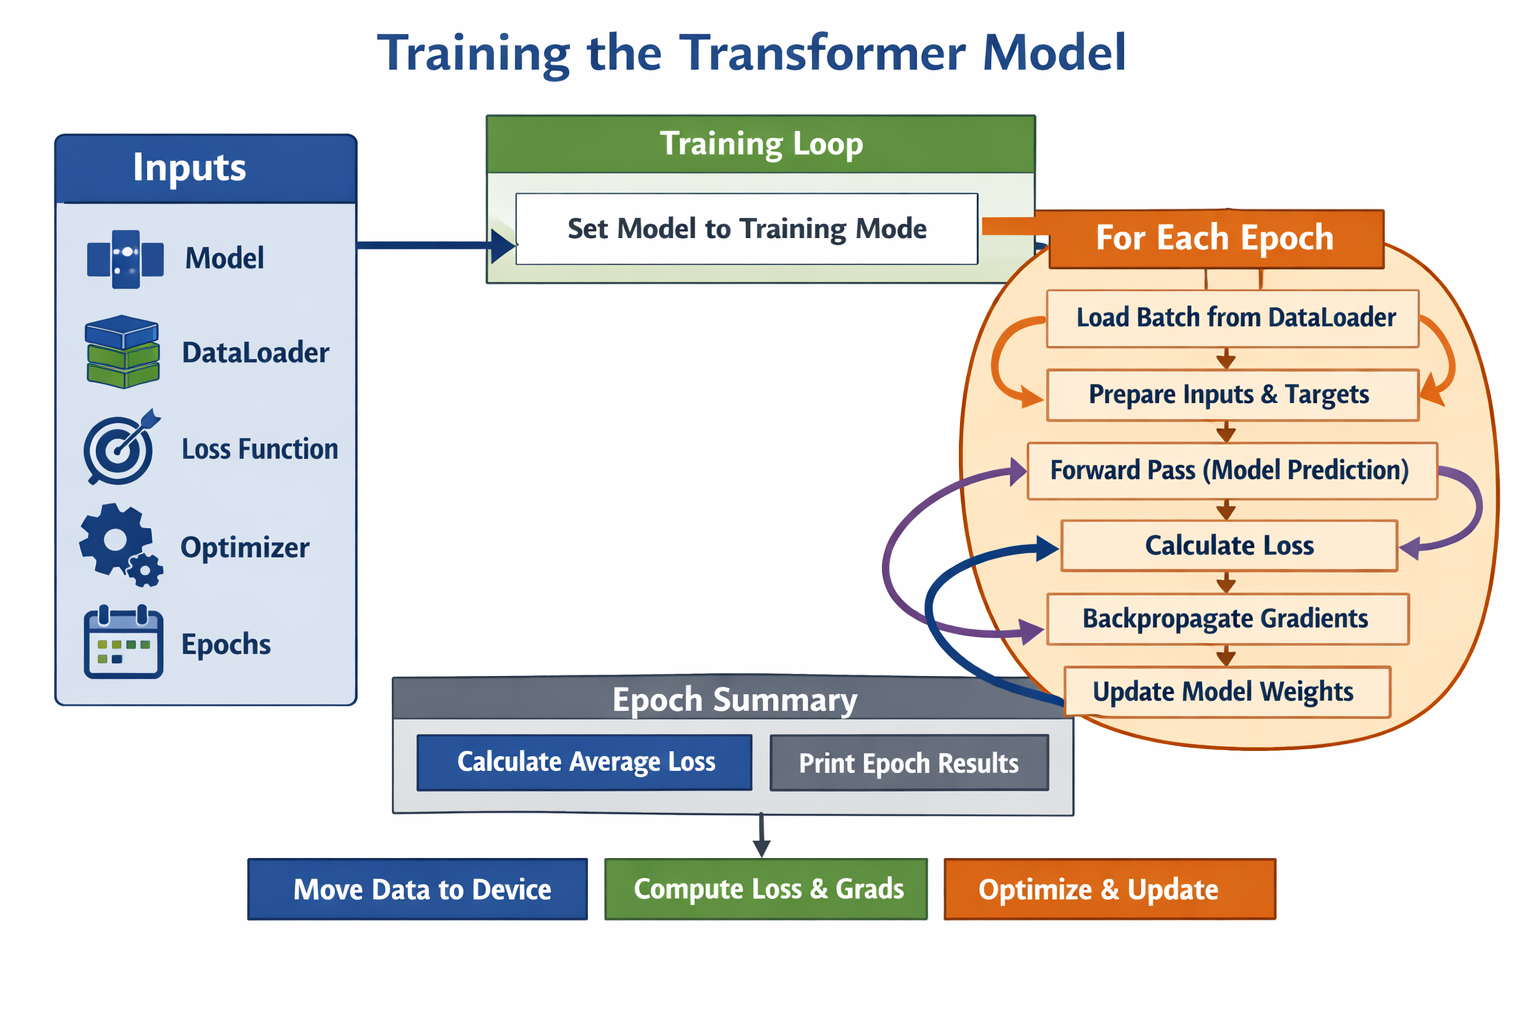

In [28]:
#Defines thetraining process over a specified number of epochs.

def train(model, dataloader, loss_function, optimiser, epochs):
    model.train()
    for epoch in range(epochs): #iterates for the specified number of epochs
        total_loss = 0
        for i, (eng_batch, spa_batch) in enumerate(dataloader):
            eng_batch = eng_batch.to(device)
            spa_batch = spa_batch.to(device)
            # Decoder preprocessing
            target_input = spa_batch[:, :-1]
            target_output = spa_batch[:, 1:].contiguous().view(-1)
            # Zero grads
            optimiser.zero_grad()
            # run model
            output = model(eng_batch, target_input)
            output = output.view(-1, output.size(-1))
            # loss\
            loss = loss_function(output, target_output)
            # gradient and update parameters
            loss.backward()
            optimiser.step()
            total_loss += loss.item()

        avg_loss = total_loss/len(dataloader)
        print(f'Epoch: {epoch}/{epochs}, Loss: {avg_loss:.4f}')



In [29]:
# preparing to train the Transformer model
BATCH_SIZE = 64
dataset = EngSpaDataset(eng_sentences, spa_sentences, eng_word2idx, spa_word2idx)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

In [30]:
#initializes the Transformer model with a set of parameters
model = Transformer(d_model=512, num_heads=8, d_ff=2048, num_layers=6,
                    input_vocab_size=eng_vocab_size, target_vocab_size=spa_vocab_size,
                    max_len=MAX_SEQ_LEN, dropout=0.1)

In [31]:
model = model.to(device)
loss_function = nn.CrossEntropyLoss(ignore_index=0) # using cross entropy and ignoring predictions for padding tokens
optimiser = optim.Adam(model.parameters(), lr=0.0001)


In [32]:
train(model, dataloader, loss_function, optimiser, epochs = 10)

Epoch: 0/10, Loss: 3.5635
Epoch: 1/10, Loss: 2.1757
Epoch: 2/10, Loss: 1.6799
Epoch: 3/10, Loss: 1.3584
Epoch: 4/10, Loss: 1.1132
Epoch: 5/10, Loss: 0.9141
Epoch: 6/10, Loss: 0.7551
Epoch: 7/10, Loss: 0.6302
Epoch: 8/10, Loss: 0.5365
Epoch: 9/10, Loss: 0.4702


In the next cell we define three Python functions essential for preparing input, interpreting output, and performing the actual translation using the transformer model

**sentence_to_indices(sentence, word2idx)**  
Converts a raw sentence into a list of numerical indices using a word-to-index dictionary. Unknown words default to the <unk> token.

**indices_to_sentence(indices, idx2word)**  
Translates a list of indices back into a readable sentence using an index-to-word dictionary, ignoring padding tokens.

**translate_sentence(model, sentence, eng_word2idx, spa_idx2word, ...)**  
Core translation function that:

*  Preprocesses the input sentence

*    Converts it to tensor format

*  Initializes the decoder with a <sos> token

*  Iteratively predicts the next token using the model

*  Stops at <eos> or max length

*  Converts predicted indices into a final translated sentence



In [33]:


def sentence_to_indices(sentence, word2idx):
    return [word2idx.get(word, word2idx['<unk>']) for word in sentence.split()]

def indices_to_sentence(indices, idx2word):
    return ' '.join([idx2word[idx] for idx in indices if idx in idx2word and idx2word[idx] != '<pad>'])

def translate_sentence(model, sentence, eng_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device='cpu'):
    model.eval()
    sentence = preprocess_sentence(sentence)
    input_indices = sentence_to_indices(sentence, eng_word2idx)
    input_tensor = torch.tensor(input_indices).unsqueeze(0).to(device)

    # Initialize the target tensor with <sos> token
    tgt_indices = [spa_word2idx['<sos>']]
    tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            output = model(input_tensor, tgt_tensor)
            output = output.squeeze(0)
            next_token = output.argmax(dim=-1)[-1].item()
            tgt_indices.append(next_token)
            tgt_tensor = torch.tensor(tgt_indices).unsqueeze(0).to(device)
            if next_token == spa_word2idx['<eos>']:
                break

    return indices_to_sentence(tgt_indices, spa_idx2word)

In [34]:
#Iterates through a list of test sentences
#Uses translate_sentence() to generate Spanish translations
#Prints both the input and translated output for each example

def evaluate_translations(model, sentences, eng_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device='cpu'):
    for sentence in sentences:
        translation = translate_sentence(model, sentence, eng_word2idx, spa_idx2word, max_len, device)
        print(f'Input sentence: {sentence}')
        print(f'Traducción: {translation}')
        print()

# Example sentences to test the translator + our 10 sentences
test_sentences = [
    "Hello, how are you?",
    "I am learning artificial intelligence.",
    "Artificial intelligence is great.",
    "Good night!",
    "I’m a bit tired.",
    "I don’t have a strong opinion.",
    "I’m on top of the world.",
    "I appreciate it.",
    "Please forgive me.",
    "Pleased to meet you.",
    "Hey, I don’t think we’ve met.",
    "It was nice talking to you.",
    "Thanks for returning my call.",
    "	I’m not certain.",
]

# Assuming the model is trained and loaded
# Set the device to 'cpu' or 'cuda' as needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Evaluate translations
evaluate_translations(model, test_sentences, eng_word2idx, spa_idx2word, max_len=MAX_SEQ_LEN, device=device)


Input sentence: Hello, how are you?
Traducción: <sos> hola como estas <eos>

Input sentence: I am learning artificial intelligence.
Traducción: <sos> estoy aprendiendo inteligencia artificial <eos>

Input sentence: Artificial intelligence is great.
Traducción: <sos> la inteligencia artificial es genial <eos>

Input sentence: Good night!
Traducción: <sos> buenas noches <eos>

Input sentence: I’m a bit tired.
Traducción: <sos> estoy un poco cansado <eos>

Input sentence: I don’t have a strong opinion.
Traducción: <sos> no tengo una opinion opinion fuerte <eos>

Input sentence: I’m on top of the world.
Traducción: <sos> estoy en la cima del mundo <eos>

Input sentence: I appreciate it.
Traducción: <sos> lo aprecio <eos>

Input sentence: Please forgive me.
Traducción: <sos> por favor perdoname <eos>

Input sentence: Pleased to meet you.
Traducción: <sos> encantada de conocerte <eos>

Input sentence: Hey, I don’t think we’ve met.
Traducción: <sos> no creo que nos conozcamos <eos>

Input sen